In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf

2.2 Pereto Distribution Bootstrap Simulation

In [4]:
def bootstrap_pareto_mean_variance(sample_size, boot_iters=1000, alpha=3.0):
    # Generate a sample from the Pareto distribution
    original_sample = np.random.pareto(alpha, sample_size)
    
    # resample with replacement 
    resamples = np.random.choice(original_sample, size=(boot_iters, sample_size), replace=True)

    # mean for each resample
    boot_means = np.mean(resamples, axis=1)

    # variance for bootstrap means
    variance_of_means = np.var(boot_means)

    return variance_of_means

#when sample size grows
sample_sizes = [10, 100, 1000, 10000]
print("Bootstrap Simulation: Variance of the Mean (Pareto Distribution)\n")

for n in sample_sizes:
    var_mean = bootstrap_pareto_mean_variance(n)
    print(f"Sample Size: {n:<5}, Variance of Bootstrap Mean: {var_mean: .6f}")

Bootstrap Simulation: Variance of the Mean (Pareto Distribution)

Sample Size: 10   , Variance of Bootstrap Mean:  0.021399
Sample Size: 100  , Variance of Bootstrap Mean:  0.006061
Sample Size: 1000 , Variance of Bootstrap Mean:  0.001756
Sample Size: 10000, Variance of Bootstrap Mean:  0.000076


3.2 Differences-in-Differences Scenario

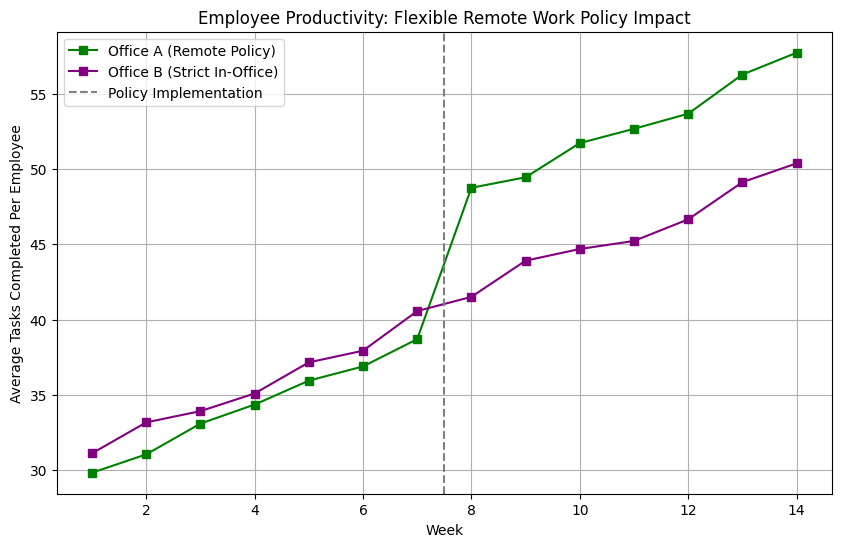

In [8]:
np.random.seed(101)

# synthetic data generation

n_employees = 100
weeks = 14
policy_week = 8

data = []
for emp in range (n_employees):
    # Office A is treated, Office B is control
    is_treated = 1 if emp >= (n_employees / 2) else 0

    # base productivity variation 
    base_tasks = np.random.normal(30, 5)

    for week in range(1, weeks + 1):
        is_post = 1 if week >= policy_week else 0

        # treatment effect: WFH policy increases productivity by 8 tasks per week 
        treatment_effect = 8 * is_treated * is_post

        # Shared time trend: company becomes busier as the quarter progresses 
        time_trend = 1.5 * week 

        # initial group difference with Office A starting at a lower baseline
        group_diff = -3 * is_treated

        # random fluctuations
        noise = np.random.normal(0, 3)

        tasks_completed = base_tasks + treatment_effect + time_trend + group_diff + noise

        data.append({
            'employee': emp, 
            'week': week,
            'Office_A_Treated': is_treated,
            'Post_Policy': is_post,
            'Tasks_Completed': tasks_completed
        })
df_remote = pd.DataFrame(data)

# aggregate for plotting
summary_remote = df_remote.groupby(['week', 'Office_A_Treated'])['Tasks_Completed'].mean().unstack()

plt.figure(figsize=(10, 6))
plt.plot(summary_remote.index, summary_remote[1], marker='s', label='Office A (Remote Policy)', color='green')
plt.plot(summary_remote.index, summary_remote[0], marker='s', label='Office B (Strict In-Office)', color='purple')
plt.axvline(x=policy_week - 0.5, color='gray', linestyle='--', label='Policy Implementation')
plt.title('Employee Productivity: Flexible Remote Work Policy Impact')
plt.xlabel('Week')
plt.ylabel('Average Tasks Completed Per Employee')
plt.legend()
plt.grid(True)
plt.show()

Differences-in-Differences Regression

In [12]:
# Formula: Outcome ~ Treatment + Post + (Treatment * Post)
did_model_remote = smf.ols('Tasks_Completed ~ Office_A_Treated * Post_Policy', data=df_remote).fit()

print("DiD Model Summary: Remote Work Policy")
print("-" * 60)

# interaction coefficient is the causal estimator
print(f"Treatment Effect on Tasks Completed: {did_model_remote.params['Office_A_Treated:Post_Policy']:.3f} tasks/week")
print(f"p-value: {did_model_remote.pvalues['Office_A_Treated:Post_Policy']:.4f}")
print("-" * 60)
print(did_model_remote.summary())

DiD Model Summary: Remote Work Policy
------------------------------------------------------------
Treatment Effect on Tasks Completed: 8.267 tasks/week
p-value: 0.0000
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:        Tasks_Completed   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     539.4
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          9.88e-233
Time:                        19:48:42   Log-Likelihood:                -4734.8
No. Observations:                1400   AIC:                             9478.
Df Residuals:                    1396   BIC:                             9499.
Df Model:                           3                                         
Covariance Type:            nonrobust                      

4.1 Equal-Width Binning

C:\Users\santo\AppData\Local\Temp\ipykernel_16528\4147572021.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_4_2_a.groupby(pd.cut(df_4_2_a['X'], bins=50))['Y'].mean().plot(ax=ax1, marker='o', linestyle='-', color='blue')
C:\Users\santo\AppData\Local\Temp\ipykernel_16528\4147572021.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_4_2_b.groupby(pd.cut(df_4_2_b['X2'], bins=50))['Y2'].mean().plot(ax=ax2, marker='o', linestyle='-', color='orange')


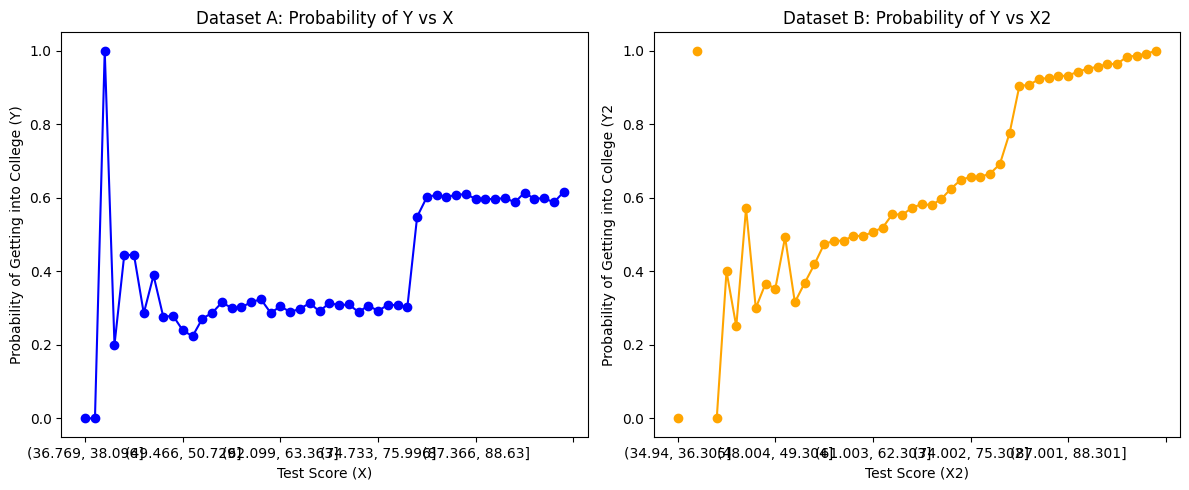

In [16]:
df_4_2_a = pd.read_csv("homework_4.2.a.csv")
df_4_2_b = pd.read_csv("homework_4.2.b.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_4_2_a.groupby(pd.cut(df_4_2_a['X'], bins=50))['Y'].mean().plot(ax=ax1, marker='o', linestyle='-', color='blue')
ax1.set_title('Dataset A: Probability of Y vs X')
ax1.set_xlabel('Test Score (X)')
ax1.set_ylabel('Probability of Getting into College (Y)')

df_4_2_b.groupby(pd.cut(df_4_2_b['X2'], bins=50))['Y2'].mean().plot(ax=ax2, marker='o', linestyle='-', color='orange')
ax2.set_title('Dataset B: Probability of Y vs X2')
ax2.set_xlabel('Test Score (X2)')
ax2.set_ylabel('Probability of Getting into College (Y2')

plt.tight_layout()
plt.show()


4.2 College Outcome vs Test Score

C:\Users\santo\AppData\Local\Temp\ipykernel_16528\2597316226.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_narrow['treated'] = (df_narrow['X'] >= 80).astype(int)
C:\Users\santo\AppData\Local\Temp\ipykernel_16528\2597316226.py:6: Fut

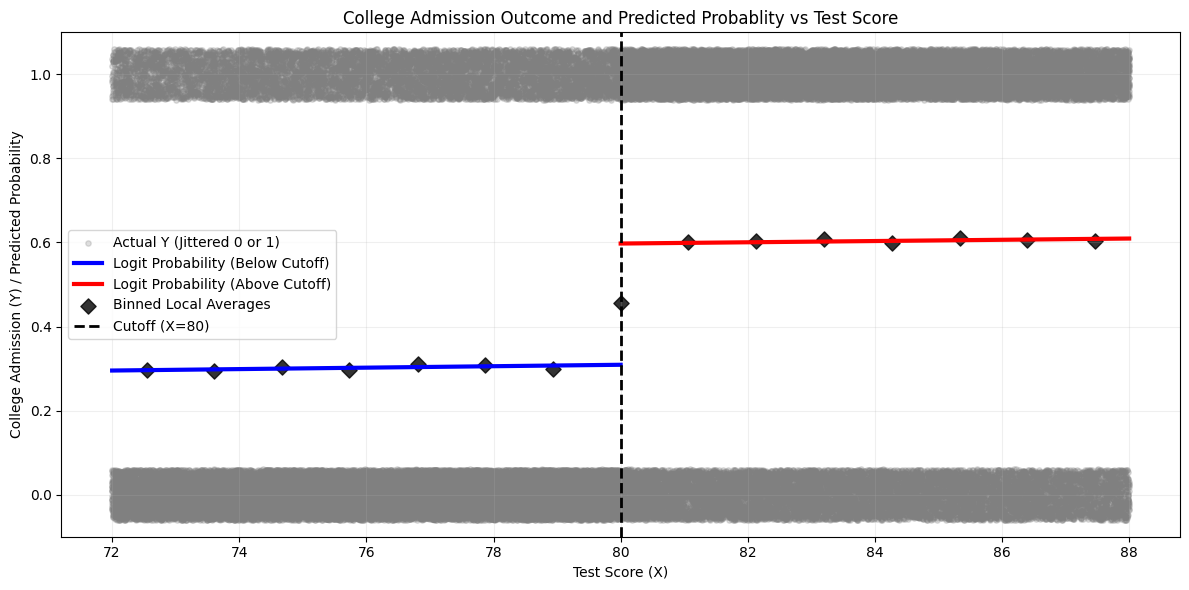

In [18]:
df_a = pd.read_csv("homework_4.2.a.csv")

df_narrow = df_a[(df_a['X'] >= 72) & (df_a['X'] <= 88)].copy()

df_narrow['treated'] = (df_narrow['X'] >= 80).astype(int)
df_narrow['X_centered'] = df_narrow['X'] - 80

logit_model = smf.logit('Y ~ treated * X_centered', data=df_narrow).fit(disp=0)
df_narrow['Y_pred_prob'] = logit_model.predict(df_narrow)

np.random.seed(42)

df_narrow['Y_jitter'] = df_narrow['Y'] + np.random.uniform(-0.06, 0.06, size=len(df_narrow))

plt.figure(figsize=(12, 6))

plt.scatter(df_narrow['X'], df_narrow['Y_jitter'], alpha=0.25, color='gray', s=15, label='Actual Y (Jittered 0 or 1)')

df_un = df_narrow[df_narrow['X'] < 80].sort_values('X')
df_tr = df_narrow[df_narrow['X'] >= 80].sort_values('X')

plt.plot(df_un['X'], df_un['Y_pred_prob'], color='blue', linewidth=3, label='Logit Probability (Below Cutoff)')
plt.plot(df_tr['X'], df_tr['Y_pred_prob'], color='red', linewidth=3, label='Logit Probability (Above Cutoff)')

binned_means = df_narrow.groupby(pd.cut(df_narrow['X'], bins=15))[['X', 'Y']].mean()
plt.scatter(binned_means['X'], binned_means['Y'], color='black', alpha=0.8,s=60, marker='D', label='Binned Local Averages')

plt.axvline(x=80, color='black', linestyle='--', linewidth=2, label='Cutoff (X=80)')

plt.title('College Admission Outcome and Predicted Probablity vs Test Score')
plt.xlabel('Test Score (X)')
plt.ylabel('College Admission (Y) / Predicted Probability')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()